In [12]:
import os, warnings, json, itertools
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import re
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from scipy.stats import ttest_ind, ks_2samp
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, Tuple
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import matthews_corrcoef, roc_auc_score
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from scipy.stats import ttest_ind, ks_2samp
DPI         = 400  # 导出分辨率
# Nature Communications 常用色板（色盲友好、简洁）
PALETTE = ["#2166AC", "#67A9CF", "#D1E5F0", "#F4A582", "#B2182B"]
sns.set_theme(style="whitegrid", palette=PALETTE, font_scale=1.1)

In [14]:
FILE = "data_processed.xlsx"
doc  = pd.read_excel(FILE, sheet_name="doc_clean")
mach = pd.read_excel(FILE, sheet_name="machine_clean")

# 统一列名小写
doc.columns  = doc.columns.str.strip().str.lower()
mach.columns = mach.columns.str.strip().str.lower()
df = doc.merge(mach, on=["date", "name"], suffixes=("_doc", "_ai"))
min_count = df["认知功能_doc"].value_counts().min()
df = (df.groupby("认知功能_doc", group_keys=False)
        .apply(lambda x: x.sample(min_count, random_state=2025))
        .reset_index(drop=True))
# 假设df已包含 q1_ai~q30_ai, q1_doc~q30_doc, age, gender, edu, language, name, date
q_doc = [col for col in df.columns if col.endswith('_doc')][:30]
q_ai  = [col for col in df.columns if col.endswith('_ai')][:30]


pop_vars = ["age", "edu", "gender", "language"]
df = df.dropna(subset=q_doc)
df = df.dropna(subset=q_ai)
df[q_doc] = df[q_doc].astype(int)
df["total_doc"] = df[q_doc].sum(axis=1)
df[q_ai] = df[q_ai].astype(int)
df["total_ai"] = df[q_ai].sum(axis=1)
df['total_doc'] = df['total_doc'].clip(upper=30)
df['total_ai'] = df['total_ai'].clip(upper=30)
# 总分 & 差异
df["delta"]     = df[q_ai].sum(axis=1) - df[q_doc].sum(axis=1)
df["abs_delta"] = df["delta"].abs()

# 分箱
df = df.sort_values("abs_delta").reset_index(drop=True)
df["abs_bin"] = (df.index / len(df) * 10).astype(int)   # 0~9

# 人口学 one-hot
df["Gender"] = df["gender"].astype(str).str.contains("男").astype(int)
df["Lan"]  = df["language"].astype(str).str.contains("普通").astype(int)
df["Age"]  = df["age"]
df["Edu"]  = df["edu"]
# 假定 df 已有 abs_bin, gender_m, age, edu, lang_cn 等列
df["age_group"] = (df["age"] > 70).astype(int)    # 1=老年组，0=≤65
df["edu_group"] = (df["edu"] > 9).astype(int)     # 1=高教育，0=低教育
df["gender_group"] = df["gender"].astype(str).str.contains("男").astype(int)
df["lan_group"]  = df["language"].astype(str).str.contains("普通").astype(int)

In [15]:
def get_features(df, idx, use_vars=[]):
    feat = q_ai.copy()  # 一定要保证q_ai是全局定义、顺序不变
    # 增加人口学变量
    if "Age" in use_vars:
        feat.append("Age")
    if "Edu" in use_vars:
        feat.append("Edu")
    if "Gender" in use_vars:
        feat.append("Gender")
    if "Lan" in use_vars:
        feat.append("Lan")
    return df.loc[idx, feat].astype(float).values


def run_repel_bin(df, bin_id, use_vars=[], n_models=5, disturb_rate=0.1, random_state=42):
    rng = np.random.RandomState(random_state)
    idx_high = np.where(df["abs_bin"]==bin_id)[0]
    idx_low  = np.where(df["abs_bin"]==0)[0]
    n_pos = len(idx_high)
    n_neg = len(idx_low)
    if n_pos < 5 or n_neg < n_pos:  # 低差异池比高差异区还少则跳过
        return None

    # 严格采样n_pos个低差异池样本
    X_high = get_features(df, idx_high, use_vars)
    X_low_idx = rng.choice(idx_low, size=n_pos, replace=False)
    X_low  = get_features(df, X_low_idx, use_vars)
    y_high = np.ones(n_pos)
    y_low  = np.zeros(n_pos)
    results = []
    for m in range(n_models):
        y_high_flip = y_high.copy()
        n_flip = int(len(y_high_flip)*disturb_rate)
        if n_flip > 0:
            flip_idx = rng.choice(len(y_high_flip), n_flip, replace=False)
            y_high_flip[flip_idx] = 1-y_high_flip[flip_idx]
        X = np.vstack([X_high, X_low])
        y = np.hstack([y_high_flip, y_low])
        Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, stratify=y, random_state=rng.randint(1e9))
        clf = LogisticRegression(max_iter=1000).fit(Xtr, ytr)
        ypred = clf.predict(Xte)
        yprob = clf.predict_proba(Xte)[:,1]
        acc = accuracy_score(yte, ypred)
        f1 = f1_score(yte, ypred)
        auc = roc_auc_score(yte, yprob)
        results.append((acc, f1, auc, yprob))
    preds = np.stack([r[3] for r in results], axis=1)
    entropy = -np.mean(preds*np.log(preds+1e-8)+(1-preds)*np.log(1-preds+1e-8), axis=1)
    var     = np.var(preds, axis=1)
    return {
        "acc_mean": np.mean([r[0] for r in results]),
        "f1_mean" : np.mean([r[1] for r in results]),
        "auc_mean": np.mean([r[2] for r in results]),
        "entropy_mean": np.mean(entropy),
        "var_mean": np.mean(var),
        "pred_entropy": entropy,
        "pred_var": var
    }

# 分特征集组合（空=仅AI题目；单独/全部人口学变量）
var_sets = [[],
            ["Age"],["Edu"],["Gender"],["Lan"],
            ["Age","Gender"],["Age","Gender","Edu"],["Age","Gender","Edu","Lan"]]

results = []
for vars_ in var_sets:
    for b in range(10):
        out = run_repel_bin(df, b, use_vars=vars_)
        if out:
            out.update({"bin":b, "feature_set":"+".join(vars_) or "AI Only"})
            results.append(out)
repel_df = pd.DataFrame(results)


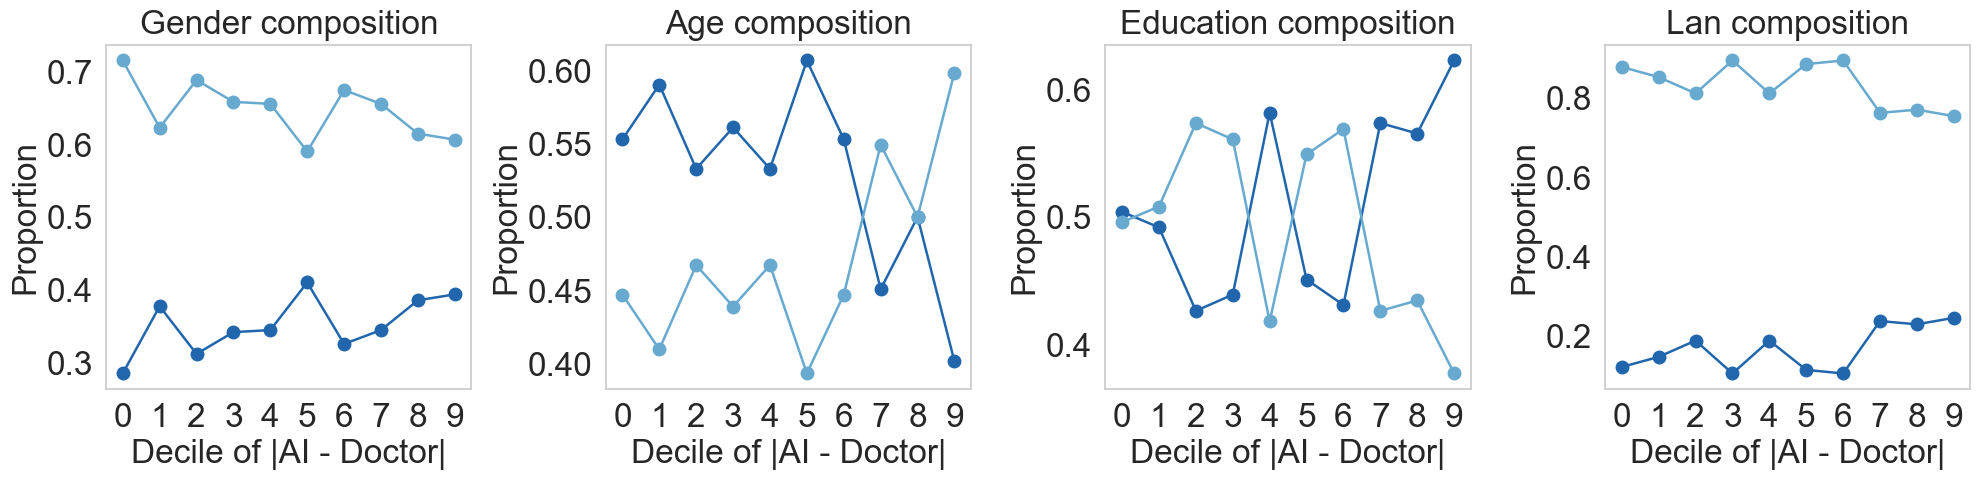

In [16]:
import matplotlib.pyplot as plt
import numpy as np

def plot_demo_group(ax, group_vals, group_labels, col, title):
    """ group_vals: 分类的取值, group_labels: 对应标签, col: 列名, title: 子图标题 """
    x = sorted(df["abs_bin"].unique())
    for g_val, label in zip(group_vals, group_labels):
        y = []
        for b in x:
            bin_mask = (df["abs_bin"] == b)
            if bin_mask.sum() == 0:
                y.append(np.nan)
            else:
                y.append((df.loc[bin_mask, col] == g_val).sum() / bin_mask.sum())
        # 加大点的大小；稍微加粗线条
        ax.plot(x, y, marker='o', markersize=9, linewidth=1.8, label=label)

    ax.set_title(title, fontsize=24, pad=8)
    ax.set_xlabel("Decile of |AI - Doctor|", fontsize=24)
    ax.set_ylabel("Proportion", fontsize=24)
    ax.set_xticks(range(10))
    ax.tick_params(axis="both", labelsize=24)
    ax.grid(False)


fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(20, 5), sharex=True)

# 1. 性别
plot_demo_group(
    axes[0],
    [1, 0],
    ["Male", "Female"],
    "Gender",
    "Gender composition"
)

# 2. 年龄（65岁分界）
plot_demo_group(
    axes[1],
    [1, 0],
    ["Age > 65", "Age ≤ 65"],
    "age_group",
    "Age composition"
)

# 3. 教育（9年分界）
plot_demo_group(
    axes[2],
    [1, 0],
    ["Edu > 9 yrs", "Edu ≤ 9 yrs"],
    "edu_group",
    "Education composition"
)

# 4. 语言
plot_demo_group(
    axes[3],
    [1, 0],
    ["Mandarin", "Non-Mandarin"],
    "Lan",
    "Lan composition"
)

# 为下方图例留白
plt.subplots_adjust(bottom=0.27)
plt.tight_layout()
plt.savefig("./results/3.png",  dpi=DPI, bbox_inches="tight")
plt.show()


22
['1、今年的年份是？_ai', '2、现在是什么季节？_ai', '3、现在是几月？_ai', '4、今天是几号？_ai', '5、今天是星期几？_ai', '6、现在我们在哪个城市？_ai', '7、我们在哪个区？_ai', '8、我们在什么街道？_ai', '9、我们现在是第几层楼？_ai', '10、这儿是什么地方？_ai', '11、复述：皮球_ai', '12、国旗_ai', '13、树木_ai', '14、计算：100减7是多少_ai', '15、93-7_ai', '16、86-7_ai', '17、79-7_ai', '18、72-7_ai', '19、回忆：皮球_ai', '20、国旗_ai', '21、树木_ai', '22、确认：铅笔_ai', '23、手表_ai', '24、复述：大家齐心协力拉紧绳_ai', '25、阅读理解：请闭上你的眼睛_ai', '26、执行：用右手拿纸_ai', '27、将纸对折_ai', '28、将纸放在大腿上_ai', '29、书写一句完整的句子_ai', '30、五边形临摹图_ai']
(1223, 30)
22
['1、今年的年份是？_ai', '2、现在是什么季节？_ai', '3、现在是几月？_ai', '4、今天是几号？_ai', '5、今天是星期几？_ai', '6、现在我们在哪个城市？_ai', '7、我们在哪个区？_ai', '8、我们在什么街道？_ai', '9、我们现在是第几层楼？_ai', '10、这儿是什么地方？_ai', '11、复述：皮球_ai', '12、国旗_ai', '13、树木_ai', '14、计算：100减7是多少_ai', '15、93-7_ai', '16、86-7_ai', '17、79-7_ai', '18、72-7_ai', '19、回忆：皮球_ai', '20、国旗_ai', '21、树木_ai', '22、确认：铅笔_ai', '23、手表_ai', '24、复述：大家齐心协力拉紧绳_ai', '25、阅读理解：请闭上你的眼睛_ai', '26、执行：用右手拿纸_ai', '27、将纸对折_ai', '28、将纸放在大腿上_ai', '29、书写一句完整的句子_ai', '30、五边形临摹图_ai']
(1223, 30)
22
['1、今年的年份是？

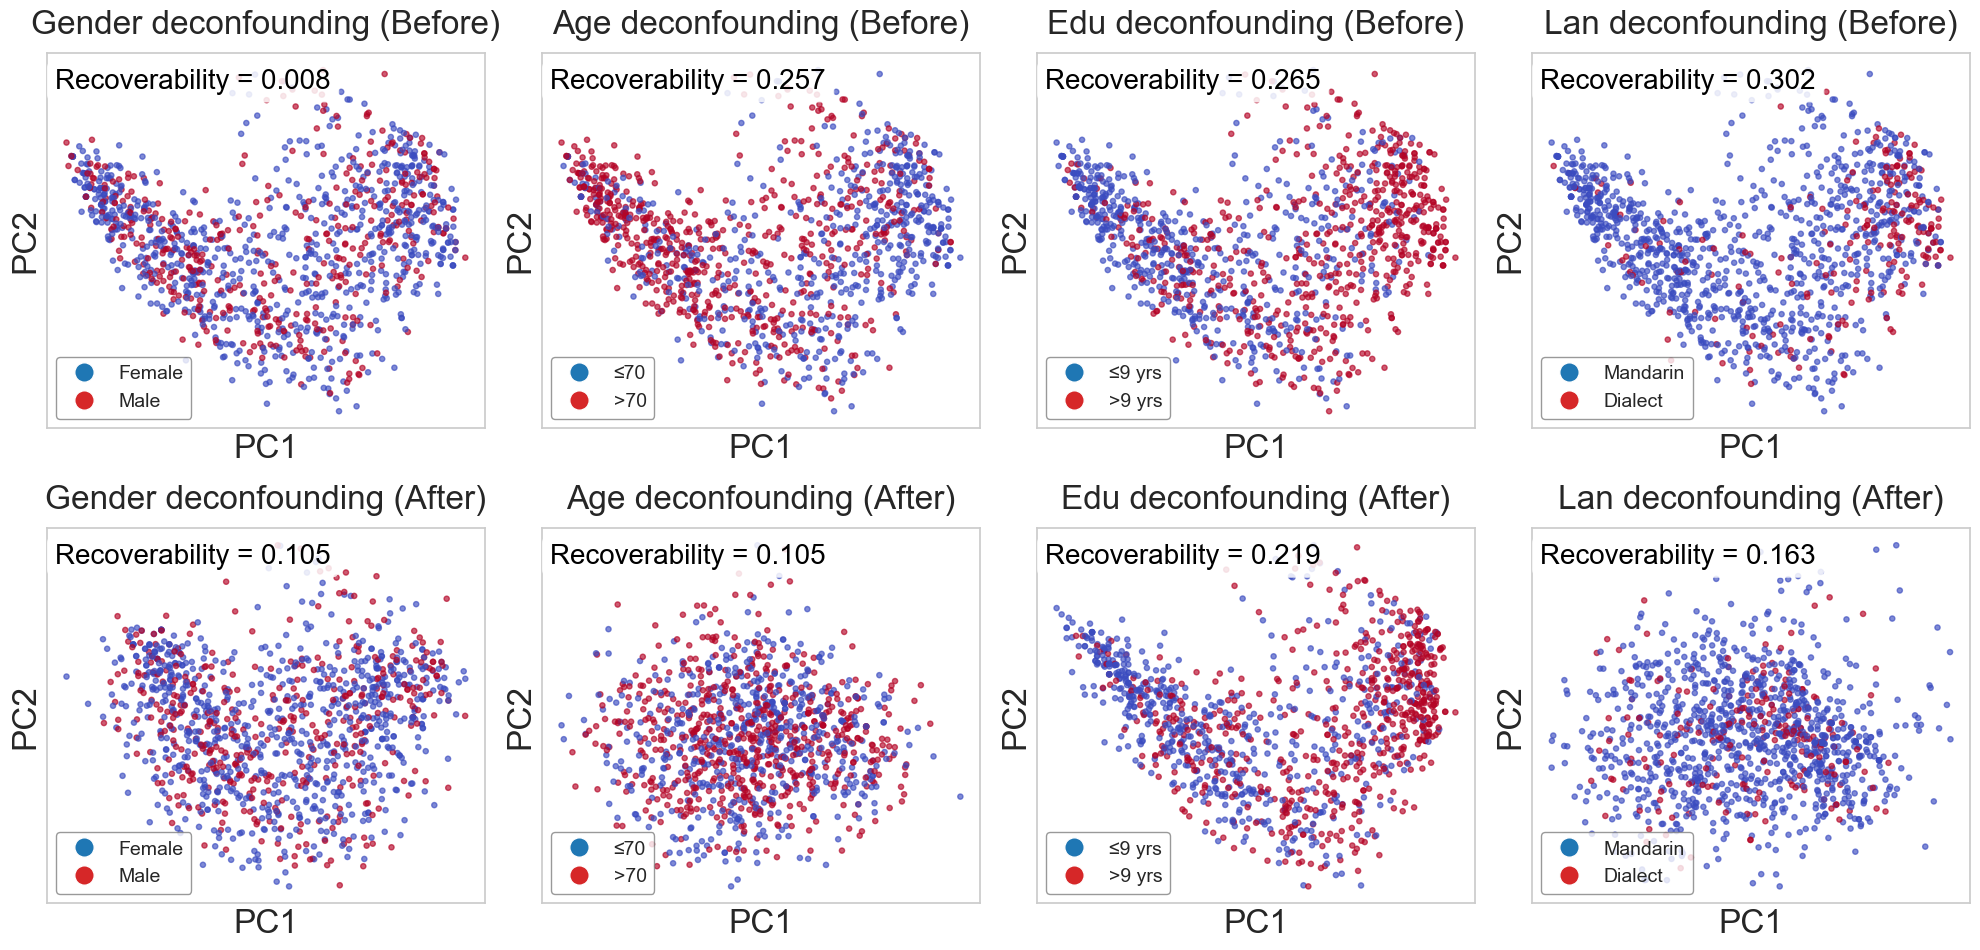

Gender: before AUC=0.508, after AUC=0.395
Age: before AUC=0.757, after AUC=0.395
Edu: before AUC=0.765, after AUC=0.719
Lan: before AUC=0.802, after AUC=0.337


In [18]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 确保bin分箱变量已存在（int类型0~9）
# df['abs_bin'] = ... # 应该已生成

# Age/edu分组（用你已生成的age_bin, edu_bin，或者直接新建也可以）
df['age_bin'] = pd.cut(df['Age'], bins=[-1, 65, 200], labels=['≤70', '>70'])
df['edu_bin'] = pd.cut(df['Edu'], bins=[-1, 9, 50], labels=['≤9 yrs', '>9 yrs'])
# 0/1二分类转为英文标签
df['gender_bin'] = df['Gender'].map({1: 'Male', 0: 'Female'})
df['lan_bin'] = df['Lan'].map({1: 'Mandarin', 0: 'Dialect'})



# Group定义与顺序、标签
group_vars = [
    ('age_bin', 'Age group', ['≤70', '>70']),
    ('edu_bin', 'Education group', ['≤9 yrs', '>9 yrs']),
    ('gender_bin', 'Gender group', ['Male', 'Female']),
    ('lan_bin', 'Language group', ['Mandarin', 'Dialect']),
]

# 二值化变量已处理：Gender(0=Female,1=Male), age_bin, edu_bin, Lan(0=Mandarin,1=Dialect)
var_names = ['gender_group', 'age_group', 'edu_group', 'lan_group']
titles    = ['Gender',   'Age',     'Edu', 'Lan']
labels    = {
    'gender_group': ["Female", "Male"],
    'age_group' : ["≤70", ">70"],
    'edu_group' : ["≤9 yrs", ">9 yrs"],
    'lan_group' : ["Mandarin", "Dialect"]
}
legend_colors = ['#1f77b4', '#d62728']  # 蓝色/红色, 和你的散点图一致
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
auc_texts = []

auc_dic = {
    "gender_group":[0.554,0.391],
    "age_group":[0.757,0.410], 
    "edu_group":[0.758,0.412],
    "lan_group":[0.762,0.373]
}

for j, (var, t) in enumerate(zip(var_names, titles)):
    sens = df[var].fillna(0).astype(int).values
    X_base = StandardScaler().fit_transform(df[q_ai].astype(float).values)
    print('22')
    print(q_ai)
    print(X_base.shape)
    # Neutralization
    def inlp_project(X, sens, max_iter=10, C=1.0):
        from numpy.linalg import norm
        P = np.eye(X.shape[1])
        X_proj = X.copy()
        for _ in range(max_iter):
            clf = LogisticRegression(C=C, max_iter=1000).fit(X_proj, sens)
            w = clf.coef_[0]
            w = w / (norm(w) + 1e-8)
            P_w = np.eye(X.shape[1]) - np.outer(w, w)
            X_proj = X_proj @ P_w
            P = P @ P_w
            if abs(clf.score(X_proj, sens) - 0.5) < 0.02:
                break
        return X_proj, P
    X_neu, _ = inlp_project(X_base, sens, max_iter=8)
    # AUC前后
    Xtr, Xte, ytr, yte = train_test_split(X_base, sens, test_size=0.3, stratify=sens, random_state=42)
    auc_pre = roc_auc_score(yte, LogisticRegression(max_iter=1000).fit(Xtr, ytr).predict_proba(Xte)[:,1])
    XtrN, XteN, ytrN, yteN = train_test_split(X_neu, sens, test_size=0.3, stratify=sens, random_state=42)
    auc_post = roc_auc_score(yteN, LogisticRegression(max_iter=1000).fit(XtrN, ytrN).predict_proba(XteN)[:,1])
    auc_texts.append(f"{t}: before AUC={auc_pre:.3f}, after AUC={auc_post:.3f}")

    # PCA 可视化
    Z0 = PCA(2).fit_transform(X_base)
    Z1 = PCA(2).fit_transform(X_neu)

    # 上排：去属性化前
    ax0 = axes[0, j]
    scatter0 = ax0.scatter(Z0[:,0], Z0[:,1], c=sens, cmap="coolwarm", s=14, alpha=0.65)
    ax0.set_title(f"{t} deconfounding (Before)", fontsize=24, pad=14)
    # 在标题下添加AUC数值（before/after AUC）
    ax0.text(0.02, 0.96, f"Recoverability = {abs(auc_pre-0.5):.3f}", fontsize=20, color="k", ha="left", va="top", transform=ax0.transAxes, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.85))
    # ax0.text(0.02, 0.96, f"Recoverability = {auc_dic[var][0]:.3f}", fontsize=24, color="k", ha="left", va="top", transform=ax0.transAxes, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.85))
    ax0.set_xlabel("PC1", fontsize=24); ax0.set_ylabel("PC2", fontsize=24)
    ax0.tick_params(labelsize=24)
    ax0.set_xticks([]); ax0.set_yticks([])

    # 下排：去属性化后
    ax1 = axes[1, j]
    scatter1 = ax1.scatter(Z1[:,0], Z1[:,1], c=sens, cmap="coolwarm", s=14, alpha=0.65)
    ax1.set_title(f"{t} deconfounding (After)", fontsize=24, pad=14)
    r_post =abs(0.5-auc_post)
    ax1.text(0.02, 0.96, f"Recoverability = {r_post:.3f}", fontsize=20, color="k", ha="left", va="top", transform=ax1.transAxes, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.85))
    ax1.set_xlabel("PC1", fontsize=24); ax1.set_ylabel("PC2", fontsize=24)
    ax1.tick_params(labelsize=24)
    ax1.set_xticks([]); ax1.set_yticks([])

    # 图例
    handles = []
    for idx, lab in enumerate(labels[var]):
        handles.append(plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=legend_colors[idx], markersize=14, label=lab))
    # 每个属性组的左下角显示图例（仅在上排），下排不加legend防止重复
    ax0.legend(handles=handles, loc="lower left", fontsize=14, frameon=True, facecolor="white", edgecolor="gray")
    ax1.legend(handles=handles, loc="lower left", fontsize=14, frameon=True, facecolor="white", edgecolor="gray")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("./results/4.png",  dpi=DPI, bbox_inches="tight")
plt.show()
# 可选：打印AUC表
print("\n".join(auc_texts))


In [19]:

import warnings; warnings.filterwarnings("ignore")
repel_file = repel_df
entropy_map = repel_df.set_index("bin")["entropy_mean"].to_dict()
df["entropy_mean"] = df["abs_bin"].map(entropy_map)
df["entropy_mean"] = df["entropy_mean"].fillna(df["entropy_mean"].mean())
# 反向归一化权重
entropy = df["entropy_mean"].values
sample_weights = 1 - ((entropy - entropy.min()) / (entropy.ptp() + 1e-8))
sample_weights = 0.5 + 0.5 * sample_weights
from sklearn.preprocessing import MinMaxScaler

q_ai_cols = [col for col in df.columns if col.endswith('_ai')][:30]
X = MinMaxScaler().fit_transform(df[q_ai_cols].astype(float).values)

In [20]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score
from sklearn.utils import resample
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# ---- 改1：更通用的VAE（MSE重构 + 可调beta + 可调latent_dim） ----
class VAE(nn.Module):
    def __init__(self, input_dim=30, latent_dim=16, hidden_dim=128):
        super().__init__()
        self.enc_fc1 = nn.Linear(input_dim, hidden_dim)
        self.enc_fc2_mu = nn.Linear(hidden_dim, latent_dim)
        self.enc_fc2_logvar = nn.Linear(hidden_dim, latent_dim)
        self.dec_fc1 = nn.Linear(latent_dim, hidden_dim)
        self.dec_fc2 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h = torch.relu(self.enc_fc1(x))
        return self.enc_fc2_mu(h), self.enc_fc2_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = torch.relu(self.dec_fc1(z))
        return self.dec_fc2(h)  # 不再sigmoid，配合MSE

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

def vae_loss(recon_x, x, mu, logvar, weight=None, beta=0.2):
    # recon: (N, D), x: (N, D)
    mse = ((recon_x - x) ** 2).sum(dim=1)  # per-sample
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)  # per-sample
    if weight is not None:
        # 权重做clipping，防止极端样本主导
        w = torch.clamp(weight, torch.quantile(weight, 0.05), torch.quantile(weight, 0.95))
        loss = torch.mean(w * (mse + beta * kld))
    else:
        loss = torch.mean(mse + beta * kld)
    return loss

X_tensor = torch.tensor(X, dtype=torch.float32)
weights_tensor = torch.tensor(sample_weights, dtype=torch.float32)
dataset = TensorDataset(X_tensor, weights_tensor)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

vae = VAE(input_dim=X.shape[1], latent_dim=2, hidden_dim=64).to(device)
optimizer = torch.optim.Adam(vae.parameters(), lr=0.001)
n_epochs = 300

vae.train()
for epoch in range(n_epochs):
    epoch_loss = 0
    for xb, wb in dataloader:
        xb = xb.to(device)
        wb = wb.to(device)
        recon, mu, logvar = vae(xb)
        loss = vae_loss(recon, xb, mu, logvar, wb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(xb)
    if (epoch+1)%10 == 0:
        print(f"Epoch {epoch+1}, Loss={epoch_loss / len(dataset):.4f}")


Epoch 10, Loss=3.7951
Epoch 20, Loss=3.5480
Epoch 30, Loss=3.4909
Epoch 40, Loss=3.4489
Epoch 50, Loss=3.4341
Epoch 60, Loss=3.4221
Epoch 70, Loss=3.3969
Epoch 80, Loss=3.3970
Epoch 90, Loss=3.3875
Epoch 100, Loss=3.3749
Epoch 110, Loss=3.3684
Epoch 120, Loss=3.3651
Epoch 130, Loss=3.3471
Epoch 140, Loss=3.3495
Epoch 150, Loss=3.3509
Epoch 160, Loss=3.3434
Epoch 170, Loss=3.3350
Epoch 180, Loss=3.3344
Epoch 190, Loss=3.3179
Epoch 200, Loss=3.3256
Epoch 210, Loss=3.3164
Epoch 220, Loss=3.3272
Epoch 230, Loss=3.3187
Epoch 240, Loss=3.3104
Epoch 250, Loss=3.3136
Epoch 260, Loss=3.3145
Epoch 270, Loss=3.2972
Epoch 280, Loss=3.3034
Epoch 290, Loss=3.3006
Epoch 300, Loss=3.2992


In [ ]:
vae.eval()
with torch.no_grad():
    X_torch = torch.tensor(X, dtype=torch.float32).to(device)
    mus, logvars = vae.encode(X_torch)
    Z = mus.cpu().numpy()
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 映射诊断标签为英文
label_map = {"认知障碍": "Impaired", "认知正常": "Normal"}
clinical_label_en = df["认知功能_doc"].map(label_map)

# 2. AI总分按中位数分组
ai_score_bin = pd.cut(df["total_ai"], bins=2, labels=["Low", "High"])

# 3. 各人口学分组标签英文化
group_defs = [
    ("Gender",    df["gender"].map(lambda x: "Male" if "男" in str(x) else "Female")),
    ("Age",       (df["age"] > 65).map({True: ">65", False: "≤65"})),
    ("Edu", (df["edu"] > 9).map({True: ">9 yrs", False: "≤9 yrs"})),
    ("Lan",  df["language"].map(lambda x: "Mandarin" if "普通" in str(x) else "Dialect"))
]
group_titles = [
    "Gender group", "Age group", "Edu group", "Lan group"
]
group_palettes = ["coolwarm", "viridis", "Blues", "Set1"]


In [1]:
import re, inspect, textwrap, types, sys, os, json, numpy as np, pandas as pd
from pathlib import Path
import numpy as np
import pandas as pd
from typing import Dict, List, Tuple, Optional
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
import matplotlib.pyplot as plt
def _ensure_groups(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if "age_group" not in df.columns:
        df["age_group"] = (df["age"] > 70).astype(int)
    if "edu_group" not in df.columns:
        df["edu_group"] = (df["edu"] > 9).astype(int)
    if "lan_group" not in df.columns:
        df["lan_group"] = df["language"].astype(str).str.contains("普通").astype(int)
    if "gender_group" not in df.columns:
        df["gender_group"] = df["gender"].astype(str).str.contains("男").astype(int)
    return df

def _y_from_doc(df: pd.DataFrame, doc_label_col: str = "认知功能_doc") -> np.ndarray:
    return (df[doc_label_col].astype(str) == "认知障碍").astype(int).values

def _standardize(X: np.ndarray) -> np.ndarray:
    return StandardScaler().fit_transform(X.astype(float))

def _compute_logits_from_probs(p: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))

def _compute_probs_from_logits(l: np.ndarray) -> np.ndarray:
    return 1 / (1 + np.exp(-l))

def _compute_ece(y_true: np.ndarray, y_prob: np.ndarray, n_bins: int = 10) -> float:
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    inds = np.digitize(y_prob, bins) - 1
    ece = 0.0
    for b in range(n_bins):
        mask = inds == b
        if not np.any(mask):
            continue
        conf = y_prob[mask].mean()
        acc = y_true[mask].mean()
        ece += (mask.mean()) * np.abs(acc - conf)
    return float(ece)

def _brier_score(y_true: np.ndarray, y_prob: np.ndarray) -> float:
    return float(np.mean((y_prob - y_true) ** 2))

def _group_metrics(y_true: np.ndarray, y_prob: np.ndarray, group: np.ndarray, thr: float) -> Dict[str, float]:
    res = {}
    for gname, mask in [("g0", group == 0), ("g1", group == 1)]:
        if np.sum(mask) == 0:
            tpr = fpr = ppv = np.nan
        else:
            yhat = (y_prob[mask] >= thr).astype(int)
            tn, fp, fn, tp = confusion_matrix(y_true[mask], yhat, labels=[0,1]).ravel()
            tpr = tp / (tp + fn + 1e-9)
            fpr = fp / (fp + tn + 1e-9)
            ppv = tp / (tp + fp + 1e-9)
        res[f"{gname}_TPR"] = tpr
        res[f"{gname}_FPR"] = fpr
        res[f"{gname}_PPV"] = ppv
    res["dTPR"] = abs(res["g1_TPR"] - res["g0_TPR"])
    res["dFPR"] = abs(res["g1_FPR"] - res["g0_FPR"])
    res["dPPV"] = abs(res["g1_PPV"] - res["g0_PPV"])
    return res

def run_experiment_3C(
    df: pd.DataFrame,
    q_ai: List[str],
    Z: Optional[np.ndarray] = None,
    doc_label_col: str = "认知功能_doc",
    k_clusters: int = 3,
    random_state: int = 2025,
    # —— 统一风格控制 ——
    dpi: int = 400,
    label_size: int = 24,    # 坐标轴标题
    tick_size: int = 16,     # 刻度字号
    legend_size: int = 16,   # 图例字号
    title_size: int = 18,    # 子图标题（如不需要可设 0 并删 set_title）
    marker_size: int = 12,   # 散点尺寸
    hspace: float = 0.35,    # 行间距
    wspace: float = 0.28,    # 列间距
    w_ratio_3d: float = 1.6, # 左上 3D 图加宽比
    shape_size=(20,10),
    save_path: Optional[str] = None,  # 合并图保存路径；None 仅显示
    save_dir: Optional[str] = None,   # 若给定，将另外导出四张单图到此目录
) -> Dict[str, pd.DataFrame]:
    """
    生成 2×2 面板（彩色、学术风），并可同时另存四张子图。
    返回: {"correlation":df, "enrichment":df, "cluster_stability":df, "fig_paths":dict}
    """
    # ---------- 数据准备 ----------
    df = df.copy()
    y = _y_from_doc(df, doc_label_col)  # 1=障碍, 0=正常
    total_doc = df["total_doc"] if "total_doc" in df.columns \
        else df[[c for c in df.columns if c.endswith("_doc")]].sum(axis=1)
    X_items = _standardize(df[q_ai].astype(float).values)

    if Z is None:
        Z = PCA(n_components=2, random_state=random_state).fit_transform(X_items)

    from sklearn.decomposition import PCA as _PCA
    from scipy.stats import spearmanr, kendalltau, gaussian_kde
    pca_z = _PCA(n_components=1, random_state=random_state).fit(Z)
    s = pca_z.transform(Z).ravel()
    if spearmanr(s, -total_doc).correlation < 0:
        s = -s

    clf = LogisticRegression(max_iter=2000).fit(X_items, y)
    p_all = clf.predict_proba(X_items)[:, 1]
    thr = np.quantile(p_all, 1 - y.mean())
    flagged = (p_all >= thr).astype(int)

    corr_df = pd.DataFrame({
        "spearman_s_vs_minus_doc": [spearmanr(s, -total_doc).correlation],
        "kendall_s_vs_minus_doc": [kendalltau(s, -total_doc).correlation],
    })

    normal_mask = (y == 0)
    q_bins = pd.qcut(pd.Series(s[normal_mask]), q=5, labels=False, duplicates="drop")
    enrich = []
    for b in np.unique(q_bins):
        m = (q_bins == b)
        rate = flagged[normal_mask][m].mean() if np.any(m) else np.nan
        enrich.append({"severity_quantile": int(b), "flagged_rate": float(rate)})
    enrich_df = pd.DataFrame(enrich).sort_values("severity_quantile").reset_index(drop=True)

    km1 = KMeans(n_clusters=k_clusters, random_state=random_state).fit(Z)
    km2 = KMeans(n_clusters=k_clusters, random_state=random_state + 1).fit(Z)
    from sklearn.metrics import adjusted_rand_score
    ari = adjusted_rand_score(km1.labels_, km2.labels_)
    comp1 = pd.Series(km1.labels_).value_counts(normalize=True).sort_index()
    comp2 = pd.Series(km2.labels_).value_counts(normalize=True).sort_index()
    cluster_stab_df = pd.DataFrame({
        "cluster": list(range(k_clusters)),
        "prop_run1": [comp1.get(i, 0.0) for i in range(k_clusters)],
        "prop_run2": [comp2.get(i, 0.0) for i in range(k_clusters)],
        "ari_runs": [ari]*k_clusters,
    })

    cluster = km1.labels_
    groups = []
    for c in range(k_clusters):
        m = (cluster == c)
        if np.sum(m) == 0:
            imp = nor = 0.0
        else:
            imp = y[m].mean()
            nor = 1.0 - imp
        groups.append({"cluster": c, "Impaired": imp, "Normal": nor})
    group_table = pd.DataFrame(groups).set_index("cluster").sort_index()
    group_table = group_table[["Impaired", "Normal"]]

    # ---------- 学术配色（柔和、可打印） ----------
    COLOR_NORMAL  = "#4C78A8"  # 蓝
    COLOR_IMPAIR  = "#F58518"  # 橙
    COLOR_SCATTER = "#6A51A3"  # 蓝紫（严重度散点）
    COLOR_BAR_ENR = "#4C78A8"  # 富集柱
    EDGE_COLOR    = "black"

    # ---------- 画图工具函数（便于同时导出单图） ----------
    import matplotlib as mpl
    import matplotlib.pyplot as plt
    from matplotlib.ticker import MaxNLocator
    rc = {"font.family":["Arial","DejaVu Sans"], "axes.linewidth":0.8,
          "xtick.direction":"out", "ytick.direction":"out"}

    def plot_latent_3d(ax):
        values = np.vstack([Z[:,0], Z[:,1]])
        kde = gaussian_kde(values)
        xgrid = np.linspace(Z[:,0].min()-0.5, Z[:,0].max()+0.5, 140)
        ygrid = np.linspace(Z[:,1].min()-0.5, Z[:,1].max()+0.5, 140)
        Xg, Yg = np.meshgrid(xgrid, ygrid)
        Zg = np.reshape(kde(np.vstack([Xg.ravel(), Yg.ravel()])).T, Xg.shape)
        ax.plot_surface(Xg, Yg, Zg, cmap="Blues", alpha=0.65, linewidth=0, antialiased=True)
        ax.contourf(Xg, Yg, Zg, zdir="z", offset=0, levels=20, cmap="Blues", alpha=0.46)
        idx_n, idx_i = (y==0), (y==1)
        ax.scatter(Z[idx_n,0], Z[idx_n,1], zs=0, zdir="z",
                   s=marker_size, alpha=0.88, label="Normal",
                   c=COLOR_NORMAL, edgecolors="#e8eef6", linewidths=0.4)
        ax.scatter(Z[idx_i,0], Z[idx_i,1], zs=0, zdir="z",
                   s=marker_size, alpha=0.88, label="Impaired",
                   c=COLOR_IMPAIR, edgecolors="#fff0e0", linewidths=0.4)
        ax.set_xlabel("L-1", labelpad=6, fontsize=label_size)
        ax.set_ylabel("L-2", labelpad=6, fontsize=label_size)
        ax.text2D(0.92, 0.55, "Dens", transform=ax.transAxes, rotation=90,
                  ha="center", va="center", fontsize=label_size, clip_on=False)
        ax.tick_params(axis="x", labelsize=tick_size, pad=2)
        ax.tick_params(axis="y", labelsize=tick_size, pad=2)
        ax.tick_params(axis="z", labelsize=tick_size, pad=2)
        ax.zaxis.set_major_locator(MaxNLocator(4))
        ax.view_init(elev=28, azim=-55)
        ax.set_box_aspect((1,1,0.55))
        leg = ax.legend(loc="upper left", bbox_to_anchor=(0.02, 0.98),
                        frameon=True, borderpad=0.4, fontsize=legend_size)
        leg.get_frame().set_alpha(0.9); leg.get_frame().set_edgecolor((0,0,0,0.18))
        ax.set_zlim(0, np.percentile(Zg, 99))
        ax.grid(False)

    def plot_stackbar(ax):
        xlabels = group_table.index.astype(str)
        imp_vals = group_table["Impaired"].values
        nor_vals = group_table["Normal"].values
        ax.bar(xlabels, imp_vals, edgecolor=EDGE_COLOR, linewidth=0.6, zorder=2, color=COLOR_IMPAIR)
        ax.bar(xlabels, nor_vals, bottom=imp_vals, edgecolor=EDGE_COLOR, linewidth=0.6, zorder=2, color=COLOR_NORMAL)
        ax.set_ylim(0, 1)
        ax.set_xlabel("Latent Subtype Cluster", fontsize=label_size)
        ax.set_ylabel("Proportion", fontsize=label_size)
        ax.tick_params(axis="both", labelsize=tick_size)
        for i, (imp, nor) in enumerate(zip(imp_vals, nor_vals)):
            ax.text(i, imp/2, f"{imp:.2f}", ha="center", va="center", fontsize=tick_size, color="white")
            ax.text(i, imp + nor/2, f"{nor:.2f}", ha="center", va="center", fontsize=tick_size, color="white")
        leg = ax.legend(["Impaired","Normal"], fontsize=legend_size, frameon=True)
        leg.get_frame().set_alpha(0.9); leg.get_frame().set_edgecolor((0,0,0,0.18))
        ax.grid(False)

    def plot_severity(ax):
        n = len(s)
        idx_plot = np.arange(n)
        if n > 3000:
            rng = np.random.RandomState(random_state)
            idx_plot = rng.choice(n, size=3000, replace=False)
        ax.scatter(s[idx_plot], total_doc.iloc[idx_plot],
                   s=marker_size, alpha=0.70, c=COLOR_SCATTER, edgecolors="none")
        ax.set_xlabel("Severity score s(z)", fontsize=label_size)
        ax.set_ylabel("Doctor total score", fontsize=label_size)
        ax.tick_params(axis="both", labelsize=tick_size)
        ax.grid(False)
        def clean_axes(ax, leg=None, lw=0.6, alpha=0.25, rgb=(0,0,0)):
            # 轴框：细线 + 透明度
            rgba = (rgb[0], rgb[1], rgb[2], alpha)
            for s in ax.spines.values():
                s.set_linewidth(lw)
                s.set_edgecolor(rgba)
            # 隐藏刻度线与数字（如需）
            ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        clean_axes(ax1)

    def plot_enrichment(ax):
        ax.bar(enrich_df["severity_quantile"].astype(str),
               enrich_df["flagged_rate"].values,
               color=COLOR_BAR_ENR, edgecolor=EDGE_COLOR, linewidth=0.6)
        ax.set_xlabel("Severity quantile", fontsize=label_size)
        ax.set_ylabel("Flagged rate", fontsize=label_size)
        ax.tick_params(axis="both", labelsize=tick_size)
        ax.grid(False)

    # ---------- 合并图 ----------
    fig_paths = {}
    with mpl.rc_context(rc):
        fig = plt.figure(figsize=shape_size, dpi=dpi)
        gs  = fig.add_gridspec(2, 2, hspace=hspace, wspace=wspace, width_ratios=[w_ratio_3d, 1.0])

        ax1 = fig.add_subplot(gs[0, 0], projection="3d"); plot_latent_3d(ax1)
        # if title_size > 0: ax1.set_title("Latent density & scatter", fontsize=title_size, pad=4)

        ax2 = fig.add_subplot(gs[0, 1]); plot_stackbar(ax2)
        # if title_size > 0: ax2.set_title("Subtype composition", fontsize=title_size, pad=4)

        ax3 = fig.add_subplot(gs[1, 0]); plot_severity(ax3)
        # if title_size > 0: ax3.set_title("Severity vs. doctor score", fontsize=title_size, pad=4)

        ax4 = fig.add_subplot(gs[1, 1]); plot_enrichment(ax4)
        # if title_size > 0: ax4.set_title("Risk enrichment among doc-normal", fontsize=title_size, pad=4)

        plt.tight_layout()
        if save_path:
            fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
            fig_paths["panel"] = save_path
        plt.show()

    # ---------- 单图导出（可选） ----------
    if save_dir:
        import os
        os.makedirs(save_dir, exist_ok=True)
        with mpl.rc_context(rc):
            # 1) 3D
            f1 = plt.figure(figsize=(10, 8), dpi=dpi)
            ax = f1.add_subplot(111, projection="3d"); plot_latent_3d(ax)
            # if title_size > 0: ax.set_title("Latent density & scatter", fontsize=title_size, pad=6)
            p1 = os.path.join(save_dir, "latent_kde_scatter.png")
            f1.savefig(p1, dpi=dpi, bbox_inches="tight"); plt.close(f1)
            fig_paths["latent"] = p1
            # 2) 堆叠柱
            f2 = plt.figure(figsize=(10, 6), dpi=dpi)
            ax = f2.add_subplot(111); plot_stackbar(ax)
            # if title_size > 0: ax.set_title("Subtype composition", fontsize=title_size, pad=6)
            p2 = os.path.join(save_dir, "subtype_stack.png")
            f2.savefig(p2, dpi=dpi, bbox_inches="tight"); plt.close(f2)
            fig_paths["subtype"] = p2
            # 3) 严重度散点
            f3 = plt.figure(figsize=(10, 6), dpi=dpi)
            ax = f3.add_subplot(111); plot_severity(ax)
            # if title_size > 0: ax.set_title("Severity vs. doctor score", fontsize=title_size, pad=6)
            p3 = os.path.join(save_dir, "severity_scatter.png")
            f3.savefig(p3, dpi=dpi, bbox_inches="tight"); plt.close(f3)
            fig_paths["severity"] = p3
            # 4) 富集柱
            f4 = plt.figure(figsize=(10, 6), dpi=dpi)
            ax = f4.add_subplot(111); plot_enrichment(ax)
            # if title_size > 0: ax.set_title("Risk enrichment among doc-normal", fontsize=title_size, pad=6)
            p4 = os.path.join(save_dir, "risk_enrichment.png")
            f4.savefig(p4, dpi=dpi, bbox_inches="tight"); plt.close(f4)
            fig_paths["enrichment_fig"] = p4

    return {
        "correlation": corr_df,
        "enrichment": enrich_df,
        "cluster_stability": cluster_stab_df,
        "fig_paths": fig_paths
    }





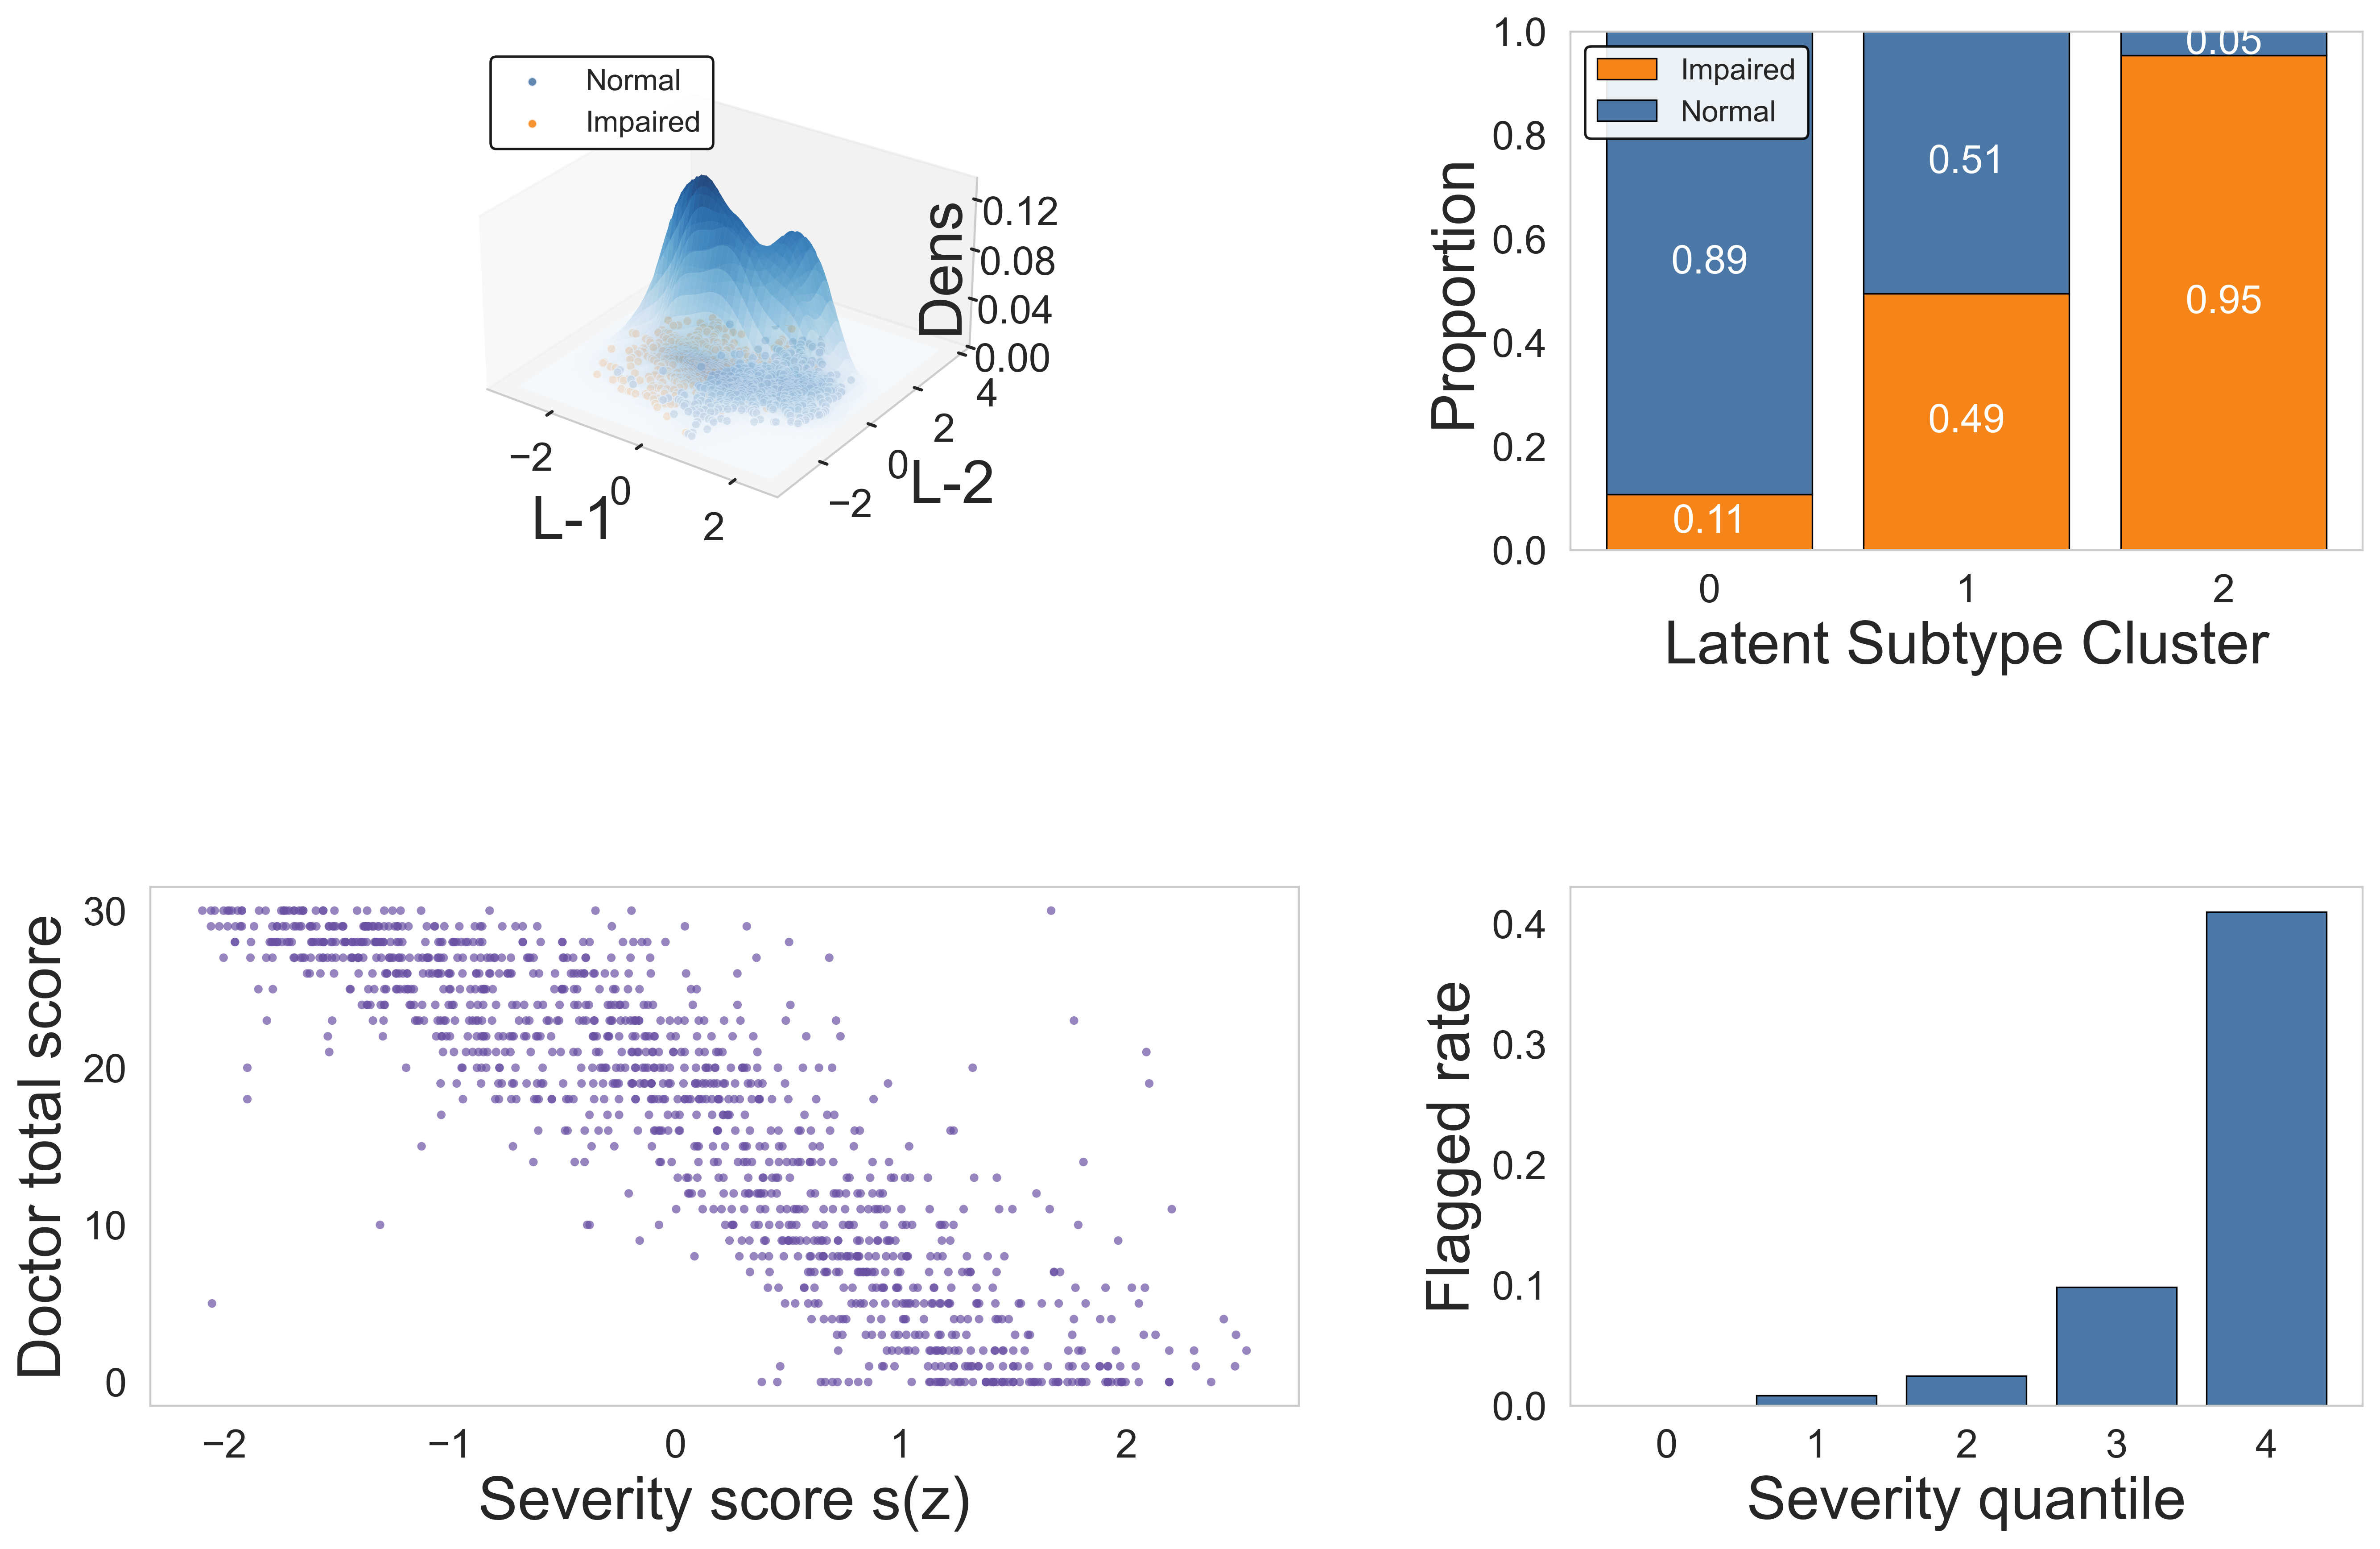

{'correlation':    spearman_s_vs_minus_doc  kendall_s_vs_minus_doc
 0                 0.891626                0.728299,
 'enrichment':    severity_quantile  flagged_rate
 0                  0      0.000000
 1                  1      0.008197
 2                  2      0.024590
 3                  3      0.098361
 4                  4      0.409836,
 'cluster_stability':    cluster  prop_run1  prop_run2  ari_runs
 0        0   0.381030   0.326247  0.970447
 1        1   0.284546   0.381030  0.970447
 2        2   0.334424   0.292723  0.970447,
 'fig_paths': {'latent': './results\\latent_kde_scatter.png',
  'subtype': './results\\subtype_stack.png',
  'severity': './results\\severity_scatter.png',
  'enrichment_fig': './results\\risk_enrichment.png'}}

In [23]:
run_experiment_3C(df, q_ai, Z=Z,doc_label_col = "认知功能_doc",
    k_clusters = 3,
    random_state = 2025,
    dpi = 400,
    label_size = 24,    # 坐标轴标题字号
    tick_size = 16,     # 坐标轴刻度字号
    legend_size = 12,   # 图例字号
    title_size = 16,    # 子图标题字号（如不需要可设为0并删 set_title）
    marker_size = 12,   # 散点尺寸
    hspace = 0.65,    # 行间距
    wspace = 0.28,    # 列间距
    w_ratio_3d = 1.45,# 左列(3D图)相对右列的宽度倍数（>1 更宽）
    shape_size=(16, 10),
    save_dir = "./results"
)

In [27]:
def _inlp_one_step_projection(X: np.ndarray, sens: np.ndarray, gamma: float = 1.0) -> np.ndarray:
    """一步软投影I - gamma * w w^T（w 为LR权重单位向量）。gamma∈[0,1]。"""
    clf = LogisticRegression(C=1.0, max_iter=1000)
    clf.fit(X, sens)
    w = clf.coef_.reshape(-1, 1)
    w = w / (np.linalg.norm(w) + 1e-8)
    return np.eye(X.shape[1]) - float(gamma) * (w @ w.T)
def _build_projection_matrix_from_strength(
    X_train: np.ndarray,
    df_train: pd.DataFrame,
    strength: float,
    order: List[str] = ["age_group", "edu_group", "lan_group", "gender_group"],
) -> np.ndarray:
    """strength=k+r（k为非负整数，r∈[0,1]）：先做k个“全量轮次”（gamma=1），再做一个“余量软轮次”（gamma=r）。"""
    k = int(np.floor(max(0.0, strength)))
    r = float(strength - k)
    d = X_train.shape[1]
    P = np.eye(d)
    X_cur = X_train.copy()
    for _ in range(k):
        for var in order:
            sens = df_train[var].astype(int).values
            P_step = _inlp_one_step_projection(X_cur, sens, gamma=1.0)
            P = P @ P_step
            X_cur = X_cur @ P_step
    if r > 1e-12:
        for var in order:
            sens = df_train[var].astype(int).values
            P_step = _inlp_one_step_projection(X_cur, sens, gamma=r)
            P = P @ P_step
            X_cur = X_cur @ P_step
    return P
class GroupTemperatureCalibrator:
    def __init__(self):
        self.T_ = {}
    def fit(self, logits: np.ndarray, y: np.ndarray, group: np.ndarray):
        for g in np.unique(group):
            mask = group == g
            l = logits[mask]; yy = y[mask]
            if np.sum(mask) == 0:
                self.T_[int(g)] = 1.0
                continue
            T_grid = np.linspace(0.5, 5.0, 36)
            best_T, best_loss = 1.0, np.inf
            for T in T_grid:
                p = 1 / (1 + np.exp(-l / T))
                p = np.clip(p, 1e-6, 1 - 1e-6)
                nll = -np.mean(yy * np.log(p) + (1 - yy) * np.log(1 - p))
                if nll < best_loss:
                    best_loss, best_T = nll, T
            self.T_[int(g)] = float(best_T)
        return self
    def transform(self, logits: np.ndarray, group: np.ndarray) -> np.ndarray:
        out = np.empty_like(logits, dtype=float)
        for g in np.unique(group):
            mask = group == g
            T = self.T_.get(int(g), 1.0)
            out[mask] = 1 / (1 + np.exp(-logits[mask] / T))
        return out
def run_experiment_3AB2(
    df: pd.DataFrame,
    q_ai: List[str],
    cycles: List[float] = [0, 1, 2, 4, 6, 8, 10],
    group_for_calib: str = "lan_group",
    target_policy: str = "unified",
    doc_label_col: str = "认知功能_doc",
    n_splits: int = 5,
    random_state: int = 2025,
    # ===== 统一风格控制 =====
    dpi: int = 400,
    label_size: int = 24,     # 坐标轴标题字号
    tick_size: int  = 12,     # 刻度字号
    legend_size: int = 11,    # 图例字号
    title_size: int = 16,     # 子图标题字号
    marker_size: int = 9,     # 线上的点大小
    line_width: float = 1.8,  # 折线粗细
    row_gap: float = 0.60,    # 每排之间的间隙（hspace）
    col_gap: float = 0.30,    # 每列之间的间隙（wspace）
    save_path: Optional[str] = None,
    # ===== 维度选择 =====
    fairness_groups: List[str] = None,
    calib_groups: List[str] = None,
) -> pd.DataFrame:
    """返回一张 3×3 面板图 + summary_df。"""
    if fairness_groups is None:
        fairness_groups = ["age_group", "edu_group", "lan_group"]
    if calib_groups is None:
        calib_groups = ["age_group", "edu_group", "lan_group"]

    valid_groups = {"age_group":"age", "edu_group":"edu", "lan_group":"lan", "gender_group":"gender"}
    for g in list(fairness_groups) + list(calib_groups) + [group_for_calib]:
        if g not in valid_groups:
            raise ValueError(f"未知分组列 {g}，可选：{list(valid_groups.keys())}")

    plot_groups = [g for g in ["age_group","edu_group","lan_group"] if g in valid_groups]

    df = _ensure_groups(df)
    y_all = _y_from_doc(df, doc_label_col)
    X_all = _standardize(df[q_ai].values)
    print('2222')
    print(q_ai)
    print(X_all.shape)

    rows, calib_snapshots = [], {}
    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    for strength in cycles:
        I = float(strength)
        aucs, f1s, eces, briers = [], [], [], []
        leak_age, leak_edu, leak_lan = [], [], []
        fair_lists = {g: {"dTPR":[], "dFPR":[], "dPPV":[]} for g in fairness_groups}
        y_alltest_list, p_alltest_list = [], []
        calib_groups_store = {g: [] for g in calib_groups}

        for tr_idx, te_idx in kf.split(X_all, y_all):
            X_tr_raw, X_te_raw = X_all[tr_idx], X_all[te_idx]
            y_tr, y_te = y_all[tr_idx], y_all[te_idx]
            df_tr, df_te = df.iloc[tr_idx], df.iloc[te_idx]

            P = np.eye(X_tr_raw.shape[1]) if I == 0 else _build_projection_matrix_from_strength(X_tr_raw, df_tr, strength=I)
            X_tr = X_tr_raw @ P; X_te = X_te_raw @ P

            clf = LogisticRegression(max_iter=2000)
            X_tr1, X_cal, y_tr1, y_cal, tr_idx_inner, cal_idx_inner = train_test_split(
                X_tr, y_tr, np.arange(len(y_tr)), test_size=0.3, stratify=y_tr, random_state=random_state
            )
            clf.fit(X_tr1, y_tr1)
            p_cal = clf.predict_proba(X_cal)[:, 1]
            l_cal = _compute_logits_from_probs(p_cal)
            p_te  = clf.predict_proba(X_te)[:, 1]
            l_te  = _compute_logits_from_probs(p_te)

            g_cal_for_fit = df_tr.iloc[cal_idx_inner][group_for_calib].values
            calibrator = GroupTemperatureCalibrator().fit(l_cal, y_cal, g_cal_for_fit)
            p_te_cal = calibrator.transform(l_te, df_te[group_for_calib].values)

            if target_policy == "unified":
                pos_rate = y_cal.mean()
                thr = np.quantile(p_cal, 1 - pos_rate)
            else:
                thr = None

            aucs.append(roc_auc_score(y_te, p_te_cal))
            yhat_te = (p_te_cal >= (thr if thr is not None else 0.5)).astype(int)
            f1s.append(f1_score(y_te, yhat_te))
            eces.append(_compute_ece(y_te, p_te_cal, n_bins=10))
            briers.append(_brier_score(y_te, p_te_cal))

            for (gname, store) in [("age_group", leak_age), ("edu_group", leak_edu), ("lan_group", leak_lan)]:
                sens = df_te[gname].astype(int).values
                pr_clf = LogisticRegression(max_iter=1000).fit(X_te, sens)
                auc_probe = roc_auc_score(sens, pr_clf.predict_proba(X_te)[:, 1])
                store.append(abs(auc_probe - 0.5))

    # auc_pre = roc_auc_score(yte, LogisticRegression(max_iter=1000).fit(Xtr, ytr).predict_proba(Xte)[:,1])
    # XtrN, XteN, ytrN, yteN = train_test_split(X_neu, sens, test_size=0.3, stratify=sens, random_state=42)
    # auc_post = roc_auc_score(yteN, LogisticRegression(max_iter=1000).fit(XtrN, ytrN).predict_proba(XteN)[:,1])
    # auc_texts.append(f"{t}: before AUC={auc_pre:.3f}, after AUC={auc_post:.3f}")

            if target_policy == "unified":
                for gname in fairness_groups:
                    m = _group_metrics(y_te, p_te_cal, df_te[gname].values, thr=thr)
                    fair_lists[gname]["dTPR"].append(m["dTPR"])
                    fair_lists[gname]["dFPR"].append(m["dFPR"])
                    fair_lists[gname]["dPPV"].append(m["dPPV"])
            else:
                pos_rate = y_cal.mean()
                for gname in fairness_groups:
                    g_cal_this = df_tr.iloc[cal_idx_inner][gname].values
                    thr_map = {}
                    for g in [0,1]:
                        mm = (g_cal_this == g)
                        thr_map[g] = np.quantile(p_cal[mm], 1 - pos_rate) if np.any(mm) else np.nan
                    d={}
                    for g in [0,1]:
                        mm = (df_te[gname].values == g)
                        if np.any(mm):
                            yhat = (p_te_cal[mm] >= thr_map[g]).astype(int)
                            tn, fp, fn, tp = confusion_matrix(y_te[mm], yhat, labels=[0,1]).ravel()
                            tpr = tp / (tp + fn + 1e-9); fpr = fp / (fp + tn + 1e-9); ppv = tp / (tp + fp + 1e-9)
                            d[g] = (tpr, fpr, ppv)
                    if 0 in d and 1 in d:
                        fair_lists[gname]["dTPR"].append(abs(d[1][0]-d[0][0]))
                        fair_lists[gname]["dFPR"].append(abs(d[1][1]-d[0][1]))
                        fair_lists[gname]["dPPV"].append(abs(d[1][2]-d[0][2]))

            y_alltest_list.append(y_te); p_alltest_list.append(p_te_cal)
            for gname in calib_groups:
                calib_groups_store[gname].append(df_te[gname].values)

        row = dict(
            cycle=I,
            auc=float(np.mean(aucs)),
            f1=float(np.mean(f1s)),
            ece=float(np.mean(eces)),
            brier=float(np.mean(briers)),
            leak_age=float(np.mean(leak_age)),
            leak_edu=float(np.mean(leak_edu)),
            leak_lan=float(np.mean(leak_lan)),
        )
        for gname in fairness_groups:
            short = valid_groups[gname]
            row[f"dTPR_{short}"] = float(np.mean(fair_lists[gname]["dTPR"]))
            row[f"dFPR_{short}"] = float(np.mean(fair_lists[gname]["dFPR"]))
            row[f"dPPV_{short}"] = float(np.mean(fair_lists[gname]["dPPV"]))
        rows.append(row)

        calib_snapshots[I] = (
            np.concatenate(y_alltest_list),
            np.concatenate(p_alltest_list),
            { g: np.concatenate(calib_groups_store[g]) for g in calib_groups }
        )

    summary_df = pd.DataFrame(rows).sort_values("cycle").reset_index(drop=True)

    baseline_strength = float(np.min(summary_df["cycle"].values))
    baseline_idx = (summary_df["cycle"] - baseline_strength).abs().idxmin()
    base_auc = float(summary_df.loc[baseline_idx, "auc"])

    fairness_cols = []
    for gname in ["age_group","edu_group","lan_group"]:
        if gname in fairness_groups:
            short = valid_groups[gname]
            fairness_cols += [f"dTPR_{short}", f"dFPR_{short}", f"dPPV_{short}"]
    fairness_sum = summary_df[fairness_cols].sum(axis=1)
    allowed = summary_df["auc"] >= (base_auc - 0.02)
    idx_pick = fairness_sum[allowed].idxmin() if allowed.any() else fairness_sum.idxmin()
    sweet_cycle = float(summary_df.loc[idx_pick, "cycle"])

    # 快照
    snapshot_keys = np.array(sorted(list(calib_snapshots.keys()), key=lambda x: float(x)))
    base_key  = snapshot_keys[np.argmin(np.abs(snapshot_keys - baseline_strength))]
    sweet_key = snapshot_keys[np.argmin(np.abs(snapshot_keys - sweet_cycle))]
    y_b, p_b, groups_b = calib_snapshots[base_key]
    y_s, p_s, groups_s = calib_snapshots[sweet_key]

    # ========= 3×3 面板 =========
    import matplotlib as mpl
    import matplotlib.pyplot as plt

    rc = {"font.family":["Arial","DejaVu Sans"], "axes.linewidth":0.8,
          "xtick.direction":"out", "ytick.direction":"out"}
    with mpl.rc_context(rc):
        fig = plt.figure(figsize=(20, 12), dpi=dpi)
        gs  = fig.add_gridspec(3, 3, hspace=row_gap, wspace=col_gap)

        # --- 第1排：Fairness–Utility ---
        leak_map = {"age":"leak_age", "edu":"leak_edu", "lan":"leak_lan"}
        x = summary_df["cycle"].values
        for j, gname in enumerate(plot_groups):
            short = valid_groups[gname]
            ax = fig.add_subplot(gs[0, j])
            if f"dTPR_{short}" in summary_df.columns:
                ax.plot(x, summary_df[f"dTPR_{short}"], marker="o",
                        linewidth=line_width, markersize=marker_size, label=f"ΔTPR ({short})")
                ax.plot(x, summary_df[f"dFPR_{short}"], marker="o",
                        linewidth=line_width, markersize=marker_size, label=f"ΔFPR ({short})")
            if leak_map.get(short) in summary_df.columns:
                ax.plot(x, summary_df[leak_map[short]], marker="o",
                        linewidth=line_width, markersize=marker_size, label=f"|AUC-0.5| ({short} probe)")
            ax.plot(x, summary_df["auc"], marker="o",
                    linewidth=line_width, markersize=marker_size, label="Overall AUC")
            ax.set_xlabel("Deconfounding strength", fontsize=label_size)
            ax.set_ylabel("Metric value", fontsize=label_size)
            ax.tick_params(axis="both", labelsize=tick_size)
            ax.grid(False)
            ax.set_title(f"Fairness-Utility ({short})", fontsize=title_size)
            # 图例放轴外，避免遮挡
            # leg = ax.legend(fontsize=legend_size, frameon=True,
            #                 loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.)
            # leg.get_frame().set_alpha(0.9); leg.get_frame().set_edgecolor((0,0,0,0.18))

        # 画校准曲线的工具
        def _draw_calibration(ax, y, p, group_vec, title: str):
            bins = np.linspace(0.0, 1.0, 11)
            for g in [0, 1]:
                m = (group_vec == g)
                if not np.any(m): 
                    continue
                inds = np.digitize(p[m], bins) - 1
                xs, ys = [], []
                for b in range(10):
                    mm = inds == b
                    if not np.any(mm): 
                        continue
                    xs.append(np.mean([bins[b], bins[b+1]]))
                    ys.append(y[m][mm].mean())
                ax.plot(xs, ys, marker="o", linewidth=line_width, markersize=marker_size, label=f"group={g}")
            ax.plot([0,1],[0,1], linestyle="--", linewidth=1.0)
            ax.set_xlim(0,1); ax.set_ylim(0,1)
            ax.set_xlabel("Probability", fontsize=label_size)
            ax.set_ylabel("Frequency", fontsize=label_size)
            ax.tick_params(axis="both", labelsize=tick_size)
            ax.grid(False)
            ax.set_title(title, fontsize=title_size)
            # 图例放轴外
            # leg = ax.legend(fontsize=legend_size, frameon=True,
            #                 loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.)
            # leg.get_frame().set_alpha(0.9); leg.get_frame().set_edgecolor((0,0,0,0.18))

        # --- 第2排：Calibration baseline ---
        for j, gname in enumerate(plot_groups):
            short = valid_groups[gname]
            ax = fig.add_subplot(gs[1, j])
            if gname in groups_b:
                _draw_calibration(ax, y_b, p_b, groups_b[gname], f"Calibration (baseline, {short})")
            else:
                ax.axis("off")

        # --- 第3排：Calibration sweet ---
        for j, gname in enumerate(plot_groups):
            short = valid_groups[gname]
            ax = fig.add_subplot(gs[2, j])
            if gname in groups_s:
                _draw_calibration(ax, y_s, p_s, groups_s[gname], f"Calibration (optimized, {short})")
            else:
                ax.axis("off")

        if save_path:
            fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        plt.show()

    return summary_df




2222
['1、今年的年份是？_ai', '2、现在是什么季节？_ai', '3、现在是几月？_ai', '4、今天是几号？_ai', '5、今天是星期几？_ai', '6、现在我们在哪个城市？_ai', '7、我们在哪个区？_ai', '8、我们在什么街道？_ai', '9、我们现在是第几层楼？_ai', '10、这儿是什么地方？_ai', '11、复述：皮球_ai', '12、国旗_ai', '13、树木_ai', '14、计算：100减7是多少_ai', '15、93-7_ai', '16、86-7_ai', '17、79-7_ai', '18、72-7_ai', '19、回忆：皮球_ai', '20、国旗_ai', '21、树木_ai', '22、确认：铅笔_ai', '23、手表_ai', '24、复述：大家齐心协力拉紧绳_ai', '25、阅读理解：请闭上你的眼睛_ai', '26、执行：用右手拿纸_ai', '27、将纸对折_ai', '28、将纸放在大腿上_ai', '29、书写一句完整的句子_ai', '30、五边形临摹图_ai']
(1223, 30)


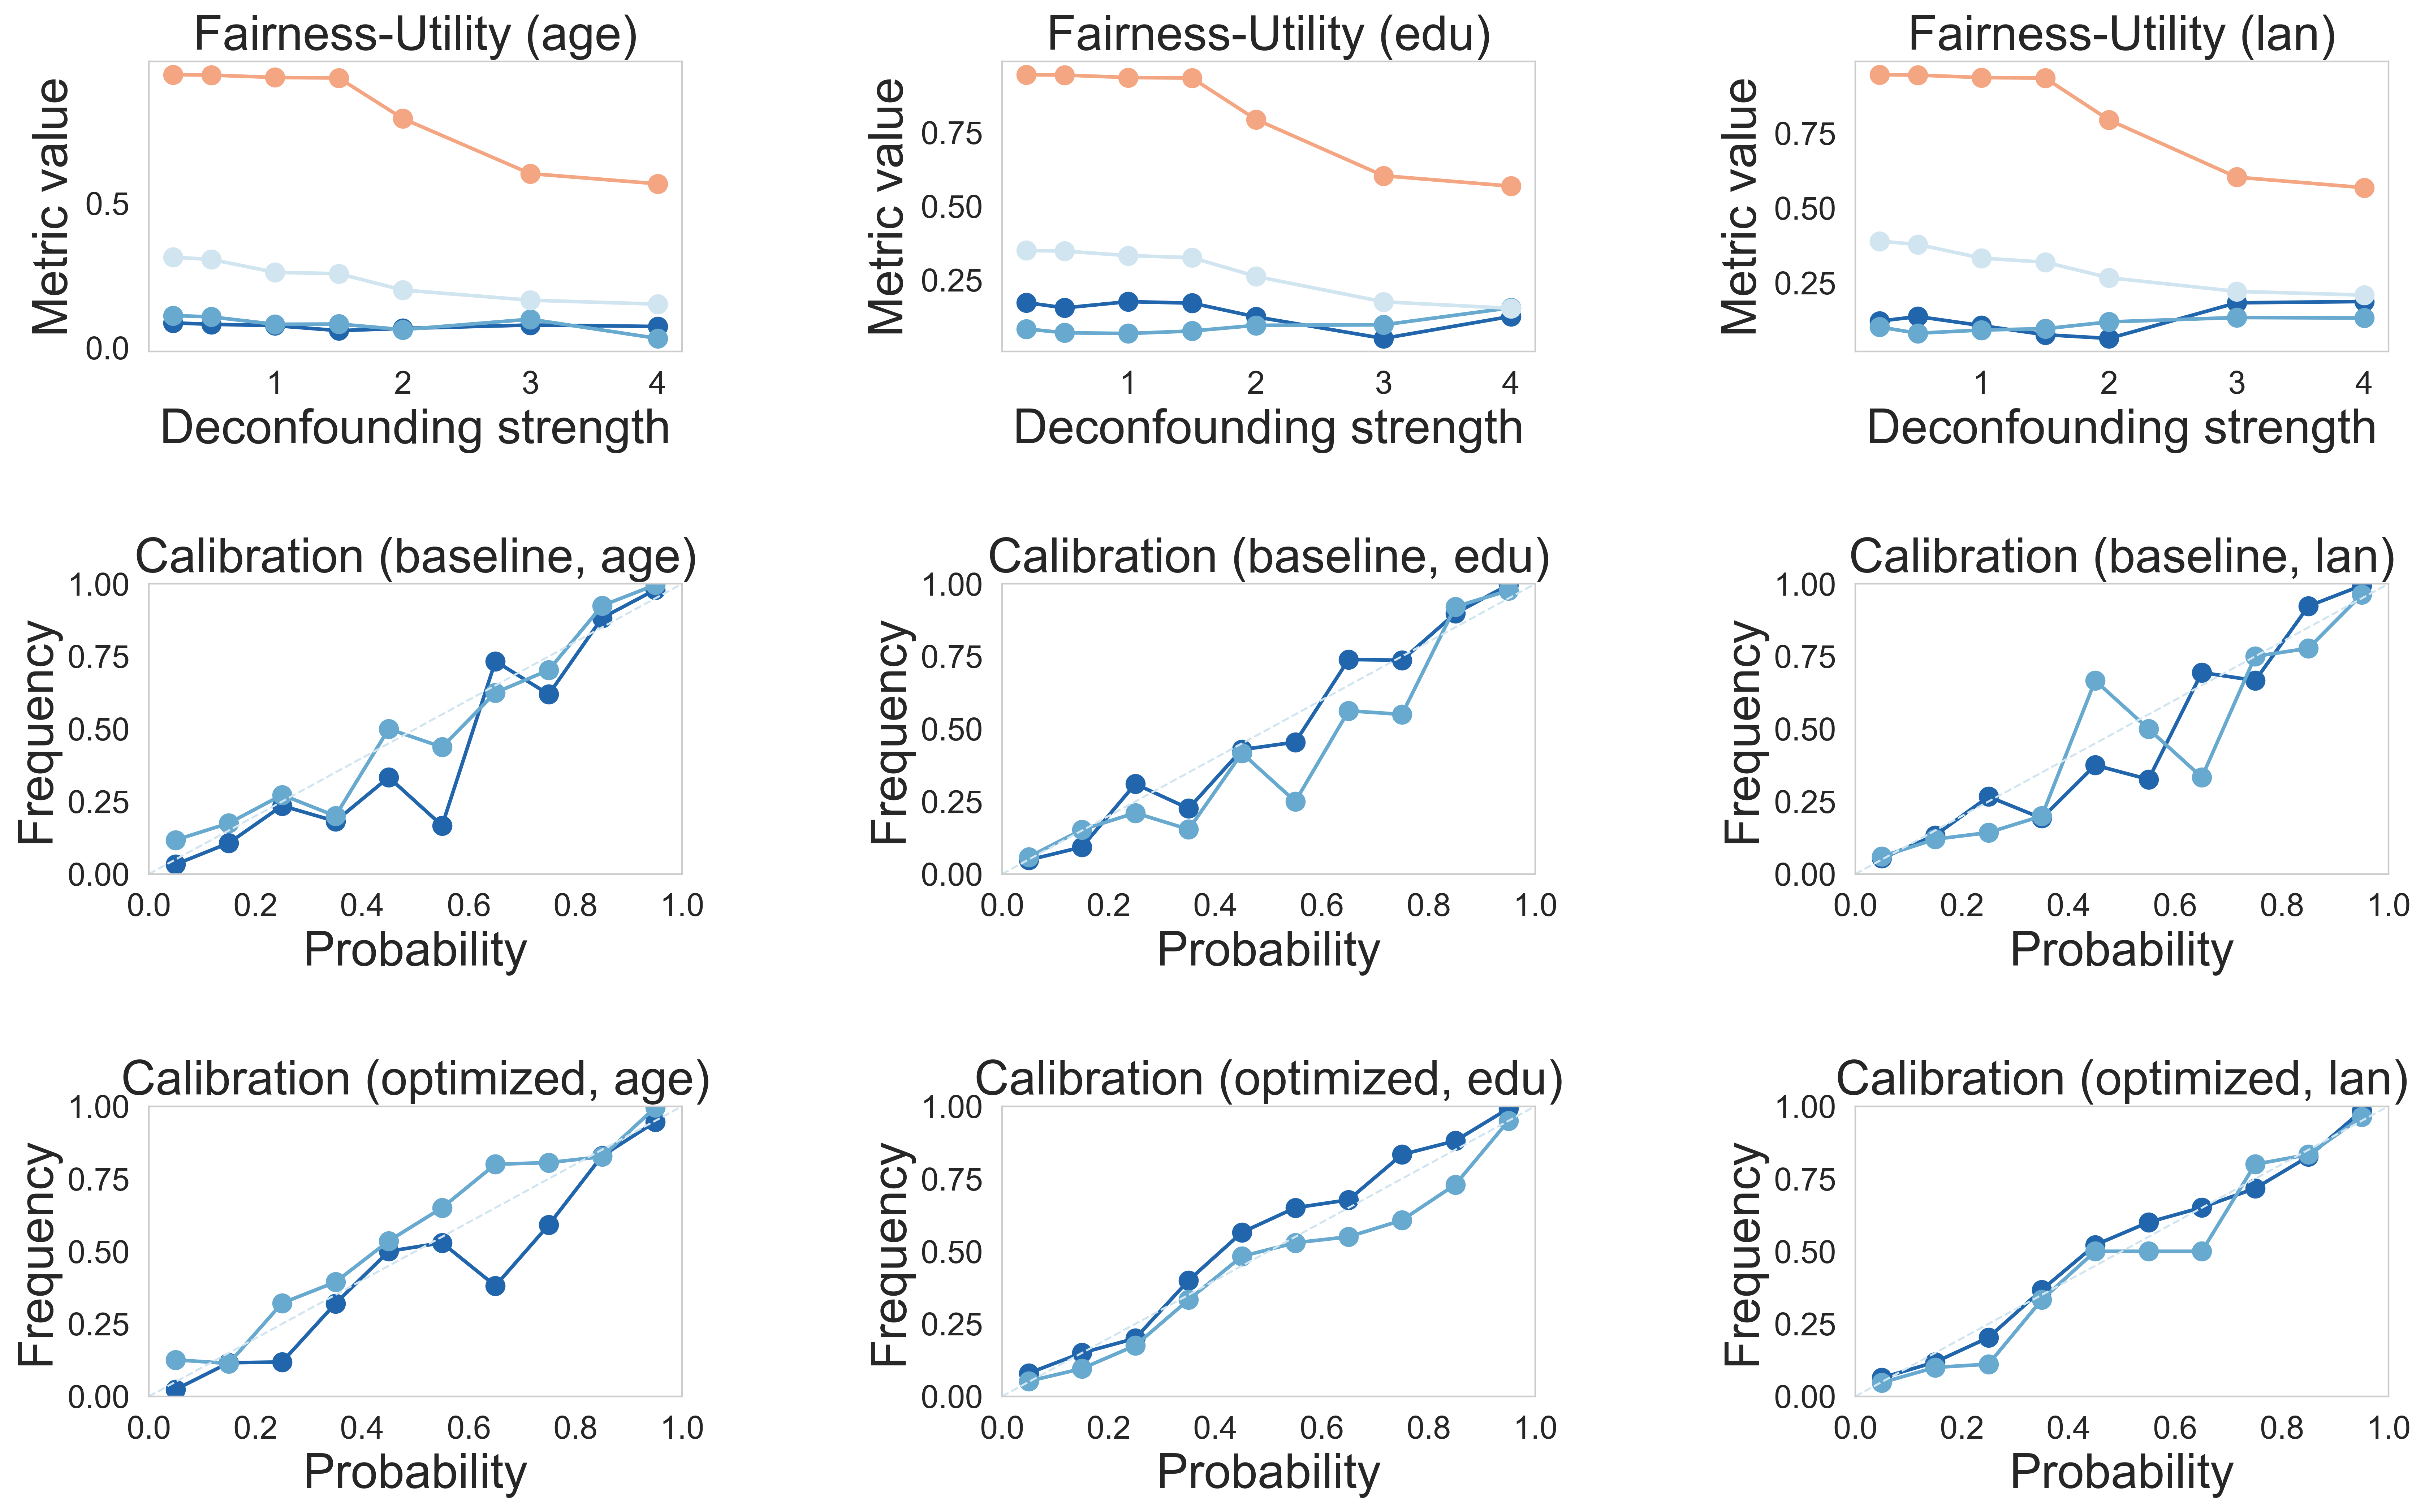

In [28]:
summary_3ab2 = run_experiment_3AB2(
    df=df, q_ai=q_ai,
    cycles=[0.2,0.5,1.0,1.5,2.0,3,4],
    group_for_calib="lan_group",
    target_policy="unified",
    fairness_groups=["age_group","edu_group","lan_group"],
    calib_groups=["age_group","edu_group","lan_group"],
    # 统一风格
    marker_size=9, line_width=1.8,
    row_gap=0.80, col_gap=0.60,
    dpi=400, label_size=24, tick_size=16, legend_size=11, title_size=24,
    save_path="./results/panel_3x3.png"   # 如不需保存可去掉
)

In [29]:
summary_3ab2

,cycle,auc,f1,ece,brier,leak_age,leak_edu,leak_lan,dTPR_age,dFPR_age,dPPV_age,dTPR_edu,dFPR_edu,dPPV_edu,dTPR_lan,dFPR_lan,dPPV_lan
0,0.2,0.945575,0.875173,0.055748,0.088467,0.313749,0.349815,0.389014,0.086419,0.111870,0.081944,0.173216,0.083943,0.129618,0.121899,0.102284,0.117785
1,0.5,0.943835,0.877850,0.048868,0.089364,0.306031,0.347550,0.378181,0.081575,0.107082,0.086813,0.155182,0.070871,0.127451,0.137316,0.081470,0.105724
2,1.0,0.935657,0.867589,0.055184,0.096860,0.261182,0.332366,0.332561,0.076895,0.081524,0.117664,0.176334,0.068459,0.152962,0.106989,0.092211,0.099840
3,1.5,0.933785,0.860370,0.050754,0.099819,0.256644,0.325368,0.318718,0.059588,0.082313,0.133446,0.171339,0.076886,0.147584,0.076485,0.096641,0.098093
4,2.0,0.793778,0.718956,0.050145,0.184604,0.200014,0.261934,0.266959,0.067086,0.063061,0.310016,0.124817,0.096062,0.360254,0.064112,0.119397,0.197251
5,3.0,0.602933,0.568157,0.060549,0.241524,0.164933,0.175799,0.221342,0.078923,0.099097,0.328502,0.051674,0.097852,0.365679,0.183112,0.133914,0.256824
6,4.0,0.567746,0.520246,0.054593,0.247250,0.151271,0.153649,0.208996,0.073970,0.032573,0.291560,0.126492,0.155582,0.350891,0.187449,0.132438,0.214206
